# Exploratory Data Analysis

This notebook explores historical match patterns used by the model.

Focus areas:

```text
target distribution
Elo difference
recent form
goals scored
draw behavior
host advantage
```

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data" / "processed"

training = pd.read_csv(DATA_DIR / "match_training_data.csv")
training["match_date"] = pd.to_datetime(training["match_date"])

training.head()

,match_id,match_date,team_a_raw_name,team_b_raw_name,team_a_id,team_b_id,team_a_is_wc2026,team_b_is_wc2026,tournament,neutral_flag,...,team_b_days_since_last_match,wins_last_5_difference,points_avg_last_5_difference,goal_diff_avg_last_5_difference,goals_for_avg_last_10_difference,goals_against_avg_last_10_difference,goal_diff_avg_last_10_difference,avg_opponent_elo_last_10_difference,days_since_last_match_difference,match_date_dt
0,HIST_000000,2014-01-01,Kuwait,Jordan,Kuwait,JOR,0,1,WAFF Championship,1.0,...,365.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,2014-01-01
1,HIST_000001,2014-01-04,Bahrain,Jordan,Bahrain,JOR,0,1,WAFF Championship,1.0,...,3.0,-1.0,-3.0,-1.0,-2.0,-1.0,-1.0,0.000000,362.0,2014-01-04
2,HIST_000002,2014-01-04,Namibia,Ghana,Namibia,GHA,0,1,Friendly,0.0,...,365.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,2014-01-04
3,HIST_000003,2014-01-04,Qatar,Kuwait,QAT,Kuwait,1,0,WAFF Championship,0.0,...,3.0,0.0,0.0,1.0,-1.0,-2.0,1.0,0.000000,362.0,2014-01-04
4,HIST_000004,2014-01-07,Qatar,Jordan,QAT,JOR,1,1,WAFF Championship,0.0,...,3.0,-1.0,0.0,2.0,1.5,-0.5,2.0,-16.931472,0.0,2014-01-07


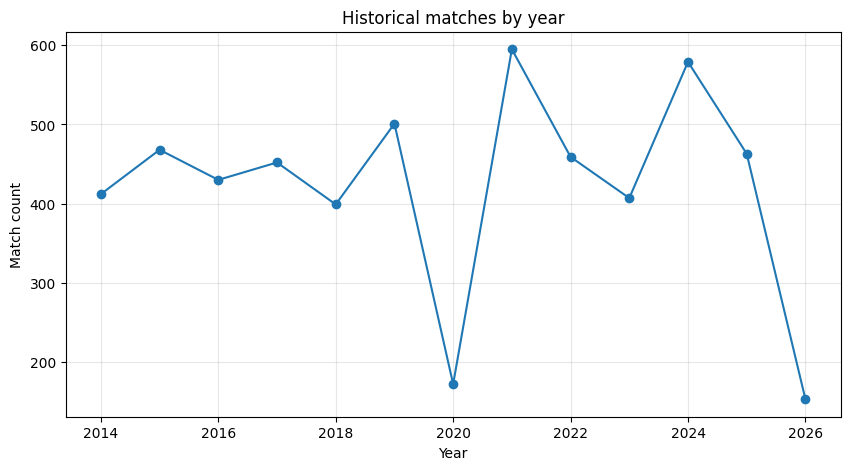

In [2]:
# Match volume by year
yearly_counts = (
    training.assign(year=training["match_date"].dt.year)
    .groupby("year")
    .size()
    .reset_index(name="match_count")
)

plt.figure(figsize=(10, 5))
plt.plot(yearly_counts["year"], yearly_counts["match_count"], marker="o")
plt.title("Historical matches by year")
plt.xlabel("Year")
plt.ylabel("Match count")
plt.grid(True, alpha=0.3)
plt.show()

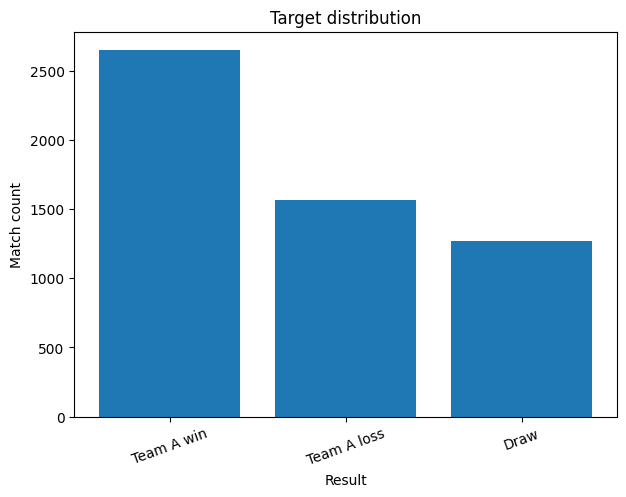

target_result
Team A win     2650
Team A loss    1567
Draw           1273
Name: count, dtype: int64

In [3]:
# Target distribution
labels = {
    0: "Team A loss",
    1: "Draw",
    2: "Team A win",
}

target_counts = training["target_result"].map(labels).value_counts()

plt.figure(figsize=(7, 5))
plt.bar(target_counts.index, target_counts.values)
plt.title("Target distribution")
plt.xlabel("Result")
plt.ylabel("Match count")
plt.xticks(rotation=20)
plt.show()

target_counts

C:\Users\tevin\AppData\Local\Temp\ipykernel_5604\2522443473.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=result_order, showfliers=False)


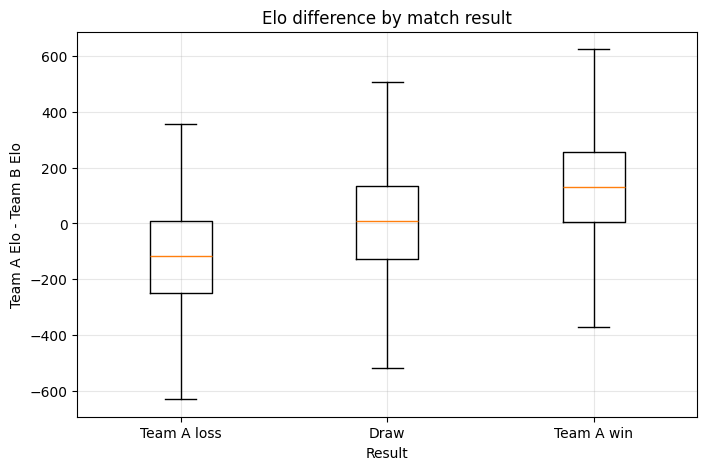

In [4]:
# Elo difference by result
result_order = ["Team A loss", "Draw", "Team A win"]
plot_data = training.copy()
plot_data["result_label"] = plot_data["target_result"].map(labels)

plt.figure(figsize=(8, 5))
data_to_plot = [
    plot_data.loc[plot_data["result_label"] == label, "pre_elo_difference"]
    for label in result_order
]
plt.boxplot(data_to_plot, labels=result_order, showfliers=False)
plt.title("Elo difference by match result")
plt.xlabel("Result")
plt.ylabel("Team A Elo - Team B Elo")
plt.grid(True, alpha=0.3)
plt.show()

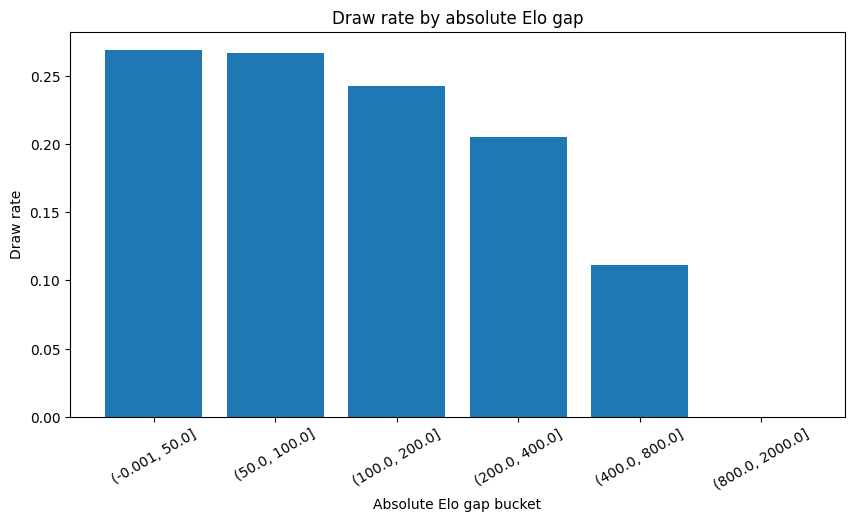

,elo_gap_bucket,is_draw
0,"(-0.001, 50.0]",0.268698
1,"(50.0, 100.0]",0.266900
2,"(100.0, 200.0]",0.242444
3,"(200.0, 400.0]",0.205463
4,"(400.0, 800.0]",0.111437
5,"(800.0, 2000.0]",0.000000


In [5]:
# Draw rate by absolute Elo gap bucket
draw_df = training.copy()
draw_df["abs_elo_gap"] = draw_df["pre_elo_difference"].abs()
draw_df["elo_gap_bucket"] = pd.cut(
    draw_df["abs_elo_gap"],
    bins=[0, 50, 100, 200, 400, 800, 2000],
    include_lowest=True
)
draw_df["is_draw"] = (draw_df["target_result"] == 1).astype(int)

draw_rate = (
    draw_df.groupby("elo_gap_bucket", observed=False)["is_draw"]
    .mean()
    .reset_index()
)

draw_rate["elo_gap_bucket"] = draw_rate["elo_gap_bucket"].astype(str)

plt.figure(figsize=(10, 5))
plt.bar(draw_rate["elo_gap_bucket"], draw_rate["is_draw"])
plt.title("Draw rate by absolute Elo gap")
plt.xlabel("Absolute Elo gap bucket")
plt.ylabel("Draw rate")
plt.xticks(rotation=30)
plt.show()

draw_rate

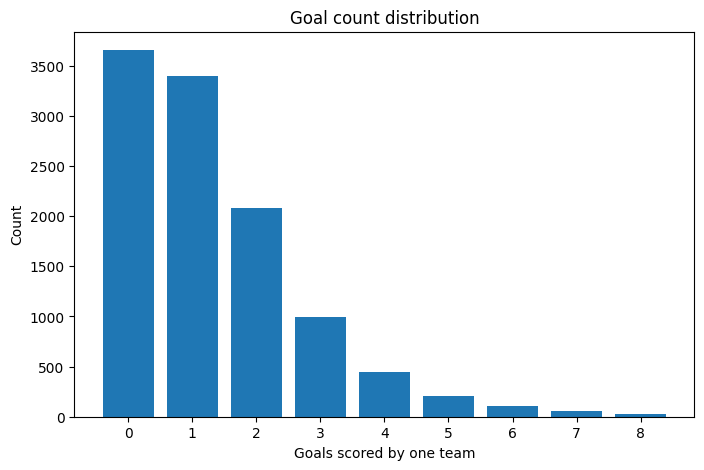

goals
0    3656
1    3396
2    2080
3     991
4     444
5     203
6     109
7      54
8      24
Name: count, dtype: int64

In [6]:
# Goal distribution
goals = pd.concat([
    training["team_a_score"].rename("goals"),
    training["team_b_score"].rename("goals"),
])

goal_counts = goals.value_counts().sort_index()
goal_counts = goal_counts[goal_counts.index <= 8]

plt.figure(figsize=(8, 5))
plt.bar(goal_counts.index.astype(str), goal_counts.values)
plt.title("Goal count distribution")
plt.xlabel("Goals scored by one team")
plt.ylabel("Count")
plt.show()

goal_counts

In [7]:
# Host advantage summary
host_summary = (
    training.groupby(["team_a_host_advantage", "team_b_host_advantage"])["target_result"]
    .value_counts(normalize=True)
    .rename("rate")
    .reset_index()
)

host_summary["result_label"] = host_summary["target_result"].map(labels)
host_summary

,team_a_host_advantage,team_b_host_advantage,target_result,rate,result_label
0,0.0,0.0,2,0.406739,Team A win
1,0.0,0.0,0,0.330325,Team A loss
2,0.0,0.0,1,0.262936,Draw
3,1.0,0.0,2,0.515674,Team A win
4,1.0,0.0,0,0.265935,Team A loss
5,1.0,0.0,1,0.218391,Draw
